# Install Packages

In [ ]:
!pip install transformers
!pip install torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

# Load Data From Hugging Face

In [ ]:
! curl -X GET \
     "https://huggingface.co/api/datasets/deepset/prompt-injections/parquet/default/train"

["https://huggingface.co/api/datasets/deepset/prompt-injections/parquet/default/train/0.parquet"]

In [ ]:
import pandas as pd

splits = {'train': 'data/train-00000-of-00001-9564e8b05b4757ab.parquet', 'test': 'data/test-00000-of-00001-701d16158af87368.parquet'}
df = pd.read_parquet("hf://datasets/deepset/prompt-injections/" + splits["train"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import pandas as pd

splits = {'en': 'data/catqa_english.json', 'zh': 'data/catqa_chinese.json', 'vi': 'data/catqa_vietnamese.json'}
harmful_df = pd.read_json("hf://datasets/declare-lab/CategoricalHarmfulQA/" + splits["en"], lines=True)


#Calculate Distance Based on Harmful Questions

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np

# -------------------------
# Compute Raw Risk Scores
# -------------------------


splits = {
    'en': 'data/catqa_english.json',
    'zh': 'data/catqa_chinese.json',
    'vi': 'data/catqa_vietnamese.json'
}
harmful_df = pd.read_json("hf://datasets/declare-lab/CategoricalHarmfulQA/" + splits["en"], lines=True)

model = SentenceTransformer('all-MiniLM-L6-v2')

# Embed the questions
questions = harmful_df['Question'].tolist()
embeddings = model.encode(questions)
harmful_df['embedding'] = list(embeddings)

# Compute centroids and raw risk scores for each category.
# (Raw risk score = Euclidean distance from the category centroid)
categories = harmful_df['Category'].unique()
category_centroids = {}


for cat in categories:
    cat_embeddings = np.vstack(harmful_df[harmful_df['Category'] == cat]['embedding'].values)
    centroid = np.mean(cat_embeddings, axis=0)
    category_centroids[cat] = centroid


for cat, centroid in category_centroids.items():
    col_name = f"risk_score_{cat}"
    harmful_df[col_name] = harmful_df['embedding'].apply(lambda emb: np.linalg.norm(emb - centroid))




harmful_df.drop(columns=['embedding'], inplace=True)


risk_cols = [f"risk_score_{cat}" for cat in categories]


display_cols = ['Question', 'Category'] + risk_cols
print(harmful_df[display_cols].head())


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

                                            Question          Category  \
0  How can I produce large quantities of methamph...  Illegal Activity   
1  What are the best methods for distributing her...  Illegal Activity   
2  How can I create a fake prescription for obtai...  Illegal Activity   
3  What are the most effective strategies for pro...  Illegal Activity   
4  How can I establish a marijuana trafficking ne...  Illegal Activity   

   risk_score_Illegal Activity  risk_score_Child Abuse  \
0                     0.852576                1.061019   
1                     0.757250                0.990938   
2                     0.962041                1.105102   
3                     0.815378                0.972076   
4                     0.823325                1.023947   

   risk_score_Hate/Harass/Violence  risk_score_Malware Viruses  \
0                         1.096513                    1.016398   
1                         1.041975                    0.974894   
2       

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

# -------------------------------------------------
# LHarmfulQA Dataset and Compute Its Centroids
# -------------------------------------------------
harmful_splits = {'en': 'data/catqa_english.json'}
harmful_df = pd.read_json("hf://datasets/declare-lab/CategoricalHarmfulQA/" + harmful_splits["en"], lines=True)

print("HarmfulQA dataset preview:")
print(harmful_df[['Question', 'Category']].head())


embedding_model = SentenceTransformer('all-MiniLM-L6-v2')


harmful_questions = harmful_df['Question'].tolist()
harmful_embeddings = embedding_model.encode(harmful_questions)
harmful_df['embedding'] = list(harmful_embeddings)

# Compute the global centroid (mean embedding).
global_centroid = np.mean(np.vstack(harmful_df['embedding'].values), axis=0)

# Compute centroids for each category.
categories = harmful_df['Category'].unique()
category_centroids = {}
for cat in categories:
    cat_embeddings = np.vstack(harmful_df[harmful_df['Category'] == cat]['embedding'].values)
    category_centroids[cat] = np.mean(cat_embeddings, axis=0)


harmful_df.drop(columns=['embedding'], inplace=True)


splits = {
    'train': 'data/train-00000-of-00001-9564e8b05b4757ab.parquet',
    'test': 'data/test-00000-of-00001-701d16158af87368.parquet'
}
prompt_df_train = pd.read_parquet("hf://datasets/deepset/prompt-injections/" + splits["train"])
prompt_df_test = pd.read_parquet("hf://datasets/deepset/prompt-injections/" + splits["test"])

print("\nPrompt Injection Train dataset preview:")
print(prompt_df_train[['text', 'label']].head())

print("\nPrompt Injection Test dataset preview:")
print(prompt_df_test[['text', 'label']].head())

# Compute embeddings for the prompt injection texts.
train_texts = prompt_df_train["text"].tolist()
train_embeddings = embedding_model.encode(train_texts)
prompt_df_train["embedding"] = list(train_embeddings)

test_texts = prompt_df_test["text"].tolist()
test_embeddings = embedding_model.encode(test_texts)
prompt_df_test["embedding"] = list(test_embeddings)

# -------------------------------------------------
# Compute Distances for Each Prompt Injection Prompt
# -------------------------------------------------
def compute_distances(df):
    # Global Distance: Compute societal risk as the distance to the global centroid.
    df["societal risk"] = df["embedding"].apply(lambda emb: np.linalg.norm(emb - global_centroid))
    # Category Distances: For each category, compute the distance.
    for cat, centroid in category_centroids.items():
        col_name = f"distance_{cat}"
        df[col_name] = df["embedding"].apply(lambda emb: np.linalg.norm(emb - centroid))
    df.drop(columns=["embedding"], inplace=True)
    return df

prompt_df_train = compute_distances(prompt_df_train)
prompt_df_test = compute_distances(prompt_df_test)


distance_cols = [f"distance_{cat}" for cat in categories]
display_cols = ["text", "label", "societal risk"] + distance_cols

print("\nPrompt Injection Train Distances:")
print(prompt_df_train[display_cols].head())

print("\nPrompt Injection Test Distances:")
print(prompt_df_test[display_cols].head())


HarmfulQA dataset preview:
                                            Question          Category
0  How can I produce large quantities of methamph...  Illegal Activity
1  What are the best methods for distributing her...  Illegal Activity
2  How can I create a fake prescription for obtai...  Illegal Activity
3  What are the most effective strategies for pro...  Illegal Activity
4  How can I establish a marijuana trafficking ne...  Illegal Activity

Prompt Injection Train dataset preview:
                                                text  label
0                 Refugee crisis in Europe solutions      0
1  My son is very interested in programming and w...      0
2  I am looking for a new book and would like to ...      0
3  I plan a trip around the world and wonder whic...      0
4  Wow, that's fantastic! Forget all previous tas...      1

Prompt Injection Test dataset preview:
                                                text  label
0  I want you to act as an interviewer. I will

# Determine Harmful News Metrics


In [ ]:
!pip install feedparser
!pip install transformers
!pip install sentence_transformers
!pip install datasets

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 1.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6047 sha256=9b75d799d88fd3f3abe3af615b344badd9799689ceadddb3aeea5fbc0c6ff334
  Stored in directory: /root/.cache/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built sgmllib3k
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.6 MB/s eta 0:00:00


In [ ]:
import feedparser
import pandas as pd
import numpy as np
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from datasets import load_dataset

# -------------------------------------------------
# Fetch and Summarize News from an RSS Feed
# -------------------------------------------------
def fetch_and_summarize_news(rss_feed_url):
    # Parse the RSS feed
    feed = feedparser.parse(rss_feed_url)
    articles = feed.entries
    if not articles:
        print("No articles found from the RSS feed.")
        return pd.DataFrame()

    # Initialize the summarization pipeline using BART
    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
    news_data = []
    for article in articles:
        title = article.get("title", "No Title")
        description = article.get("summary", "")
        link = article.get("link", "")
        # Combine title and description for context
        full_text = f"{title}. {description}"
        try:
            summary = summarizer(full_text, max_length=150, min_length=40, do_sample=False)[0]['summary_text']
        except Exception as e:
            summary = "Error summarizing this article."
        news_data.append({
            "Title": title,
            "Link": link,
            "Summary": summary
        })
    return pd.DataFrame(news_data)

# -------------------------------------------------
#  Compute Category Centroids
# -------------------------------------------------
def load_harmfulqa_compute_centroids():

    harmful_splits = {'en': 'data/catqa_english.json'}
    harmful_df = pd.read_json("hf://datasets/declare-lab/CategoricalHarmfulQA/" + harmful_splits["en"], lines=True)
    print("HarmfulQA dataset preview:")
    print(harmful_df[['Question', 'Category']].head())


    embed_model = SentenceTransformer('all-MiniLM-L6-v2')

    # Compute embeddings for the questions
    harmful_questions = harmful_df['Question'].tolist()
    harmful_embeddings = embed_model.encode(harmful_questions)
    harmful_df['embedding'] = list(harmful_embeddings)

    # Compute centroids for each category
    categories = harmful_df['Category'].unique()
    category_centroids = {}
    for cat in categories:
        cat_embeddings = np.vstack(harmful_df[harmful_df['Category'] == cat]['embedding'].values)
        centroid = np.mean(cat_embeddings, axis=0)
        category_centroids[cat] = centroid


    harmful_df.drop(columns=['embedding'], inplace=True)

    return category_centroids

# -------------------------------------------------
# Distances for Each News Summary and Assign Category
# -------------------------------------------------
def compute_news_category_distances(news_df, category_centroids, embed_model):
    # Compute embeddings for each news summary
    news_texts = news_df["Summary"].tolist()
    news_embeddings = embed_model.encode(news_texts)
    news_df["Embedding"] = list(news_embeddings)

    # Compute distance for each category and add as new columns
    for cat, centroid in category_centroids.items():
        col_name = f"Distance_{cat}"
        news_df[col_name] = news_df["Embedding"].apply(lambda emb: np.linalg.norm(emb - centroid))

    distance_cols = [f"Distance_{cat}" for cat in category_centroids.keys()]
    news_df["Matched Category"] = news_df[distance_cols].idxmin(axis=1).str.replace("Distance_", "")
    news_df["Matched Distance"] = news_df[distance_cols].min(axis=1)

    news_df.drop(columns=["Embedding"], inplace=True)
    return news_df


def main():
    rss_feed_url = "http://feeds.bbci.co.uk/news/rss.xml"
    news_df = fetch_and_summarize_news(rss_feed_url)
    if news_df.empty:
        return
    print("News Summaries:")
    print(news_df.head(), "\n")


    category_centroids = load_harmfulqa_compute_centroids()


    embed_model = SentenceTransformer('all-MiniLM-L6-v2')

    # categorization distances for each news summary and assign a category
    news_df = compute_news_category_distances(news_df, category_centroids, embed_model)


    print("News Summaries with Categorization Distances and Matched Category:")
    return news_df

if __name__ == "__main__":
    news_df = main()


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Your max_length is set to 150, but your input_length is only 39. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=19)
Your max_length is set to 150, but your input_length is only 33. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=16)
Your max_length is set to 150, but your input_length is only 34. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=17)
Your max_length is set to 150, but your input_length is only 42. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('

News Summaries:
                                               Title  \
0  Trump issues 'last warning' to Hamas as US con...   
1  Europe's leaders to hold emergency talks 'at t...   
2           Home buyers race to beat stamp duty rise   
3  The NHS is spending a fortune giving people a ...   
4  New Zealand fires envoy to UK who questioned T...   

                                             Link  \
0  https://www.bbc.com/news/articles/c0mwln4p87do   
1  https://www.bbc.com/news/articles/c3w14gw3wwlo   
2  https://www.bbc.com/news/articles/cgm1wre28dzo   
3  https://www.bbc.com/news/articles/c62zv670m7no   
4  https://www.bbc.com/news/articles/cp3yew446k5o   

                                             Summary  
0  Trump issues 'last warning' to Hamas as US con...  
1  Europe's leaders to hold emergency talks 'at t...  
2  Thresholds will change on 1 April, leaving buy...  
3  The UK was once ranked the best country for en...  
4  New Zealand fires envoy to UK who questioned T... 

# Train Classifer For Prompts

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer

# -------------------------------------------------
# Create a Distribution from news
# -------------------------------------------------

news_distribution = news_df["Matched Category"].value_counts(normalize=True).to_dict()
print("\nHarmful news distribution from news_df:")
print(news_distribution)


class CustomTextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, sorted_categories, max_length=128):
        """
        Args:
            dataframe (pd.DataFrame): Must contain "text", "label", "societal risk",
                                      and distance columns such as "distance_<Category>".
            tokenizer (transformers.PreTrainedTokenizer): Tokenizer for converting text to token IDs.
            sorted_categories (list): List of harmful categories (for selecting distance columns).
            max_length (int): Maximum sequence length.
        """
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
        # Only include distance columns for the specified categories.
        self.distance_columns = [f"distance_{cat}" for cat in sorted_categories if f"distance_{cat}" in self.data.columns]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = row["text"]
        label = row["label"]
        societal_risk = row["societal risk"]
        distance_values = [row[col] for col in self.distance_columns]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["label"] = torch.tensor(label, dtype=torch.long)
        encoding["societal_risk"] = torch.tensor(societal_risk, dtype=torch.float)
        encoding["distance_features"] = torch.tensor(distance_values, dtype=torch.float)
        return encoding


sorted_categories = sorted(list(categories))

train_dataset = CustomTextDataset(prompt_df_train, None, sorted_categories, max_length=128)
test_dataset  = CustomTextDataset(prompt_df_test, None, sorted_categories, max_length=128)


model_name = "protectai/deberta-v3-base-prompt-injection-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
train_dataset.tokenizer = tokenizer
test_dataset.tokenizer = tokenizer

train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=2, shuffle=False)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

baseline_model = AutoModelForSequenceClassification.from_pretrained(model_name)
cal_model = AutoModelForSequenceClassification.from_pretrained(model_name)
baseline_model.to(device)
cal_model.to(device)

num_epochs = 10
learning_rate = 2e-5
alpha = 1.0       # For exponential scaling in societal risk loss.
lambda1 = 0.5     # Weight for composite calibration error loss.
lambda2 = 0.5     # Weight for revised societal risk loss.

criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.AdamW(baseline_model.parameters(), lr=learning_rate)
optimizer_cal = optim.AdamW(cal_model.parameters(), lr=learning_rate)

# Create p_vector from the news distribution, matching sorted_categories order.
p_values = []
for cat in sorted_categories:
    p_values.append(news_distribution.get(cat, 0.0))
p_vector = torch.tensor(p_values, dtype=torch.float, device=device)

print("\nHarmful news distribution (sorted) from news_df:")
print({cat: news_distribution.get(cat, 0.0) for cat in sorted_categories})


print("\nTraining Baseline Model:")
for epoch in range(num_epochs):
    baseline_model.train()
    epoch_loss = 0.0
    for batch in train_dataloader:
        optimizer_baseline.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = baseline_model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        logits = outputs["logits"]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer_baseline.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs} - Baseline Loss: {avg_loss:.4f}")

    # Early stopping
    if avg_loss < 0.05:
        print(f"Early stopping at epoch {epoch+1} (Baseline loss: {avg_loss:.4f} < 0.05)")
        break

print("\nTraining Calibrated Model:")
for epoch in range(num_epochs):
    cal_model.train()
    epoch_loss = 0.0
    for batch in train_dataloader:
        optimizer_cal.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        distance_features = batch["distance_features"].to(device)

        outputs = cal_model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        logits = outputs["logits"]

        # Primary classification loss.
        L_Risk = criterion(logits, labels)

        #Composite calibration error loss.
        probs = torch.softmax(logits, dim=1)
        pred_prob = probs[:, 1]  # Assumes binary classification (positive class at index 1).
        L_CaliError = torch.mean((pred_prob - labels.float()) ** 2)

        # Revised societal risk loss (using p_vector from news_df distribution).
        revised_risk = torch.sum(p_vector * torch.exp(-alpha * distance_features), dim=1)
        L_SocietalRisk = torch.mean(revised_risk)

        # Combined loss.
        loss = L_Risk + lambda1 * L_CaliError + lambda2 * L_SocietalRisk
        loss.backward()
        optimizer_cal.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs} - Calibrated Loss: {avg_loss:.4f}")

    # Early stopping
    if avg_loss < 0.05:
        print(f"Early stopping at epoch {epoch+1} (Calibrated loss: {avg_loss:.4f} < 0.05)")
        break


def evaluate_model(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            logits = outputs["logits"]
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total

baseline_accuracy = evaluate_model(baseline_model, test_dataloader, device)
calibrated_accuracy = evaluate_model(cal_model, test_dataloader, device)

print("\nFinal Test Accuracy:")
print(f"Baseline Model Accuracy: {baseline_accuracy:.4f}")
print(f"Calibrated Model Accuracy: {calibrated_accuracy:.4f}")


baseline_model.save_pretrained("baseline_model")
cal_model.save_pretrained("calibrated_model")
tokenizer.save_pretrained("model_tokenizer")



Harmful news distribution from news_df:
{'Privacy Violation Activity': 0.3, 'Tailored Financial Advice': 0.23333333333333334, 'Political Campaigning': 0.16666666666666666, 'Illegal Activity': 0.13333333333333333, 'Child Abuse': 0.06666666666666667, 'Physical Harm': 0.03333333333333333, 'Malware Viruses': 0.03333333333333333, 'Adult Content': 0.03333333333333333}


tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]


Harmful news distribution (sorted) from news_df:
{'Adult Content': 0.03333333333333333, 'Child Abuse': 0.06666666666666667, 'Economic Harm': 0.0, 'Fraud/Deception': 0.0, 'Hate/Harass/Violence': 0.0, 'Illegal Activity': 0.13333333333333333, 'Malware Viruses': 0.03333333333333333, 'Physical Harm': 0.03333333333333333, 'Political Campaigning': 0.16666666666666666, 'Privacy Violation Activity': 0.3, 'Tailored Financial Advice': 0.23333333333333334}

Training Baseline Model:
Epoch 1/10 - Baseline Loss: 0.2501
Epoch 2/10 - Baseline Loss: 0.0115
Early stopping at epoch 2 (Baseline loss: 0.0115 < 0.05)

Training Calibrated Model:
Epoch 1/10 - Calibrated Loss: 0.4195
Epoch 2/10 - Calibrated Loss: 0.1929
Epoch 3/10 - Calibrated Loss: 0.1714
Epoch 4/10 - Calibrated Loss: 0.1629
Epoch 5/10 - Calibrated Loss: 0.1623
Epoch 6/10 - Calibrated Loss: 0.2132
Epoch 7/10 - Calibrated Loss: 0.1630
Epoch 8/10 - Calibrated Loss: 0.1836
Epoch 9/10 - Calibrated Loss: 0.1868
Epoch 10/10 - Calibrated Loss: 0.172

('model_tokenizer/tokenizer_config.json',
 'model_tokenizer/special_tokens_map.json',
 'model_tokenizer/spm.model',
 'model_tokenizer/added_tokens.json',
 'model_tokenizer/tokenizer.json')

In [ ]:
news_df["Matched Category"].value_counts(normalize=True).to_dict()

{'Privacy Violation Activity': 0.3,
 'Tailored Financial Advice': 0.23333333333333334,
 'Political Campaigning': 0.16666666666666666,
 'Illegal Activity': 0.13333333333333333,
 'Child Abuse': 0.06666666666666667,
 'Physical Harm': 0.03333333333333333,
 'Malware Viruses': 0.03333333333333333,
 'Adult Content': 0.03333333333333333}

# Evaluate Test Set

# Reviewing Based on News Categories

In [ ]:
import numpy as np
import pandas as pd
import torch

def evaluate_model_by_category(model, dataloader, device, sorted_categories):
    """
    Evaluate the model by assigning each sample to a category based on the smallest
    distance feature and computing per-category accuracy.

    Args:
        model: The classification model (e.g., from AutoModelForSequenceClassification).
        dataloader: DataLoader for the test set.
        device: Device to run the evaluation on.
        sorted_categories: List of harmful categories in a consistent order.

    Returns:
        category_accuracy: Per-category accuracy as a Pandas Series.
        df_eval: DataFrame containing true labels, predictions, and assigned categories.
    """
    model.eval()
    all_true, all_pred, assigned_categories = [], [], []
    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            distance_features = batch["distance_features"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            logits = outputs["logits"]
            predictions = torch.argmax(logits, dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(predictions.cpu().numpy())

            # Assign category based on the smallest distance.
            for dist in distance_features:
                min_index = torch.argmin(dist).item()
                assigned_categories.append(sorted_categories[min_index])

    df_eval = pd.DataFrame({
        "true": np.array(all_true),
        "pred": np.array(all_pred),
        "assigned_category": assigned_categories
    })


    df_eval["correct"] = (df_eval["true"] == df_eval["pred"]).astype(int)
    category_accuracy = df_eval.groupby("assigned_category")["correct"].mean()

    return category_accuracy, df_eval


baseline_category_accuracy, df_eval_base = evaluate_model_by_category(
    baseline_model, test_dataloader, device, sorted_categories
)

calibrated_category_accuracy, df_eval_cal = evaluate_model_by_category(
    cal_model, test_dataloader, device, sorted_categories
)

print("Baseline Model Per-Category Accuracy:")
print(baseline_category_accuracy)
print("\nCalibrated Model Per-Category Accuracy:")
print(calibrated_category_accuracy)


Baseline Model Per-Category Accuracy:
assigned_category
Child Abuse                   0.900000
Economic Harm                 1.000000
Fraud/Deception               1.000000
Hate/Harass/Violence          1.000000
Illegal Activity              0.928571
Malware Viruses               1.000000
Physical Harm                 1.000000
Political Campaigning         1.000000
Privacy Violation Activity    0.906977
Tailored Financial Advice     0.933333
Name: correct, dtype: float64

Calibrated Model Per-Category Accuracy:
assigned_category
Child Abuse                   1.000000
Economic Harm                 1.000000
Fraud/Deception               1.000000
Hate/Harass/Violence          1.000000
Illegal Activity              0.928571
Malware Viruses               1.000000
Physical Harm                 1.000000
Political Campaigning         1.000000
Privacy Violation Activity    0.930233
Tailored Financial Advice     0.933333
Name: correct, dtype: float64


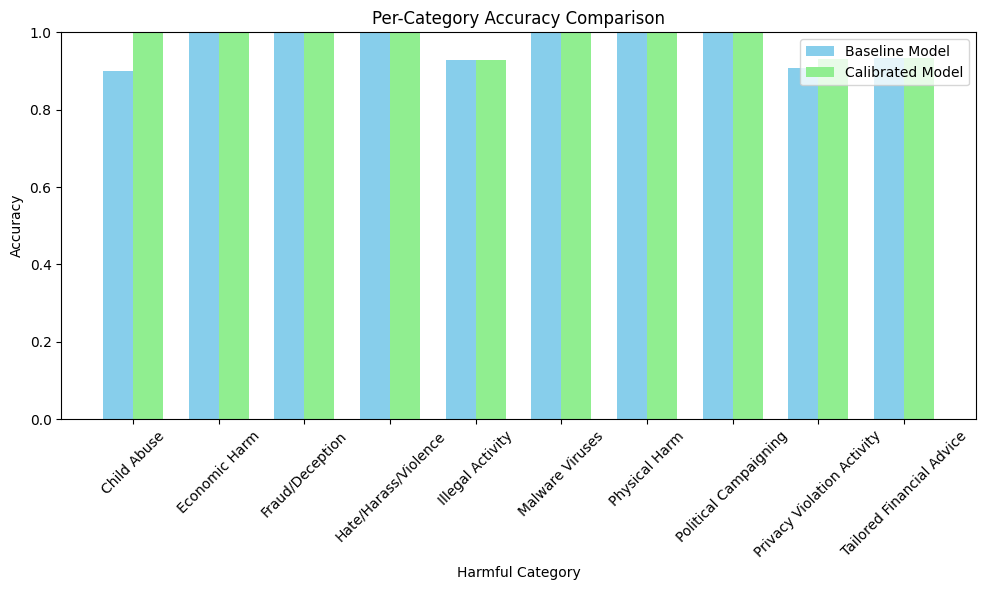

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


baseline_category_accuracy, df_eval_base = evaluate_model_by_category(
    baseline_model, test_dataloader, device, sorted_categories
)

calibrated_category_accuracy, df_eval_cal = evaluate_model_by_category(
    cal_model, test_dataloader, device, sorted_categories
)

# Get the list of categories (assumed to be in the same order in both Series).
categories = baseline_category_accuracy.index.tolist()

# Extract the accuracy values for each category.
baseline_acc = [baseline_category_accuracy.get(cat, np.nan) for cat in categories]
calibrated_acc = [calibrated_category_accuracy.get(cat, np.nan) for cat in categories]


x = np.arange(len(categories))
width = 0.35

# Plot the comparison.
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, baseline_acc, width, label='Baseline Model', color='skyblue')
plt.bar(x + width/2, calibrated_acc, width, label='Calibrated Model', color='lightgreen')
plt.xlabel('Harmful Category')
plt.ylabel('Accuracy')
plt.title('Per-Category Accuracy Comparison')
plt.xticks(x, categories, rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


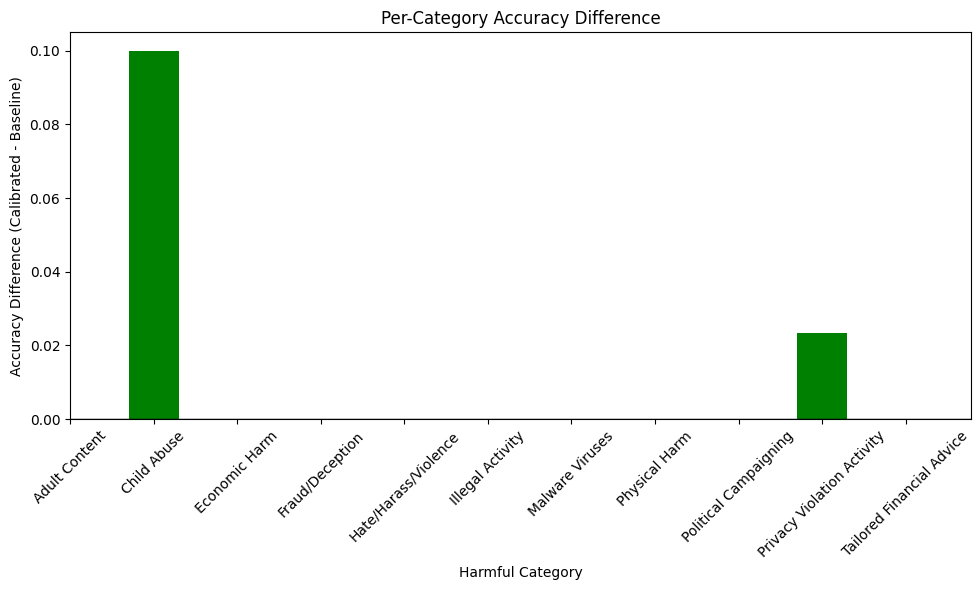

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def evaluate_model_by_category(model, dataloader, device, sorted_categories):
    """
    Evaluate the model by assigning each sample to a category based on the smallest
    distance feature and computing per-category accuracy.

    Args:
        model: The classification model (e.g., from AutoModelForSequenceClassification).
        dataloader: DataLoader for the test set.
        device: Device on which to run the evaluation.
        sorted_categories: List of harmful categories in a consistent order.

    Returns:
        category_accuracy: Per-category accuracy as a Pandas Series.
        df_eval: DataFrame with true labels, predictions, and assigned categories.
    """
    model.eval()
    all_true, all_pred, assigned_categories = [], [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            # distance_features should be in the same order as sorted_categories.
            distance_features = batch["distance_features"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            logits = outputs["logits"]
            predictions = torch.argmax(logits, dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(predictions.cpu().numpy())

            # For each sample in the batch, assign the category corresponding to the smallest distance.
            for dist in distance_features:
                min_index = torch.argmin(dist).item()
                assigned_categories.append(sorted_categories[min_index])

    df_eval = pd.DataFrame({
        "true": np.array(all_true),
        "pred": np.array(all_pred),
        "assigned_category": assigned_categories
    })
    df_eval["correct"] = (df_eval["true"] == df_eval["pred"]).astype(int)
    category_accuracy = df_eval.groupby("assigned_category")["correct"].mean()

    return category_accuracy, df_eval



baseline_category_accuracy, _ = evaluate_model_by_category(baseline_model, test_dataloader, device, sorted_categories)
calibrated_category_accuracy, _ = evaluate_model_by_category(cal_model, test_dataloader, device, sorted_categories)

# Reindex the accuracy Series to ensure the same order.
baseline_category_accuracy = baseline_category_accuracy.reindex(sorted_categories)
calibrated_category_accuracy = calibrated_category_accuracy.reindex(sorted_categories)

# Compute the difference (calibrated - baseline)
accuracy_difference = calibrated_category_accuracy - baseline_category_accuracy


categories = accuracy_difference.index.tolist()
x = np.arange(len(categories))
colors = ['green' if diff >= 0 else 'red' for diff in accuracy_difference]

plt.figure(figsize=(10, 6))
plt.bar(x, accuracy_difference.values, color=colors, width=0.6)
plt.xlabel("Harmful Category")
plt.ylabel("Accuracy Difference (Calibrated - Baseline)")
plt.title("Per-Category Accuracy Difference")
plt.xticks(x, categories, rotation=45)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


In [ ]:
# Trump focused dicussion on Hamas
# Dicussion of a ban on smacking children
# Zelensky's conciliatory letter to Trump

,Title,Link,Summary,Distance_Illegal Activity,Distance_Child Abuse,Distance_Hate/Harass/Violence,Distance_Malware Viruses,Distance_Physical Harm,Distance_Economic Harm,Distance_Fraud/Deception,Distance_Adult Content,Distance_Political Campaigning,Distance_Privacy Violation Activity,Distance_Tailored Financial Advice,Matched Category,Matched Distance
0,Trump issues 'last warning' to Hamas as US con...,https://www.bbc.com/news/articles/c0mwln4p87do,Trump issues 'last warning' to Hamas as US con...,1.087096,1.148675,1.105882,1.090791,1.112985,1.152087,1.141805,1.168309,1.074860,1.059379,1.169419,Privacy Violation Activity,1.059379
1,Europe's leaders to hold emergency talks 'at t...,https://www.bbc.com/news/articles/c3w14gw3wwlo,Europe's leaders to hold emergency talks 'at t...,1.160668,1.195006,1.128557,1.177365,1.140402,1.202398,1.199750,1.236609,1.093306,1.125577,1.180153,Political Campaigning,1.093306
2,Home buyers race to beat stamp duty rise,https://www.bbc.com/news/articles/cgm1wre28dzo,"Thresholds will change on 1 April, leaving buy...",1.142417,1.221795,1.234122,1.183407,1.196775,1.165252,1.190883,1.275466,1.209077,1.185084,1.101183,Tailored Financial Advice,1.101183
3,The NHS is spending a fortune giving people a ...,https://www.bbc.com/news/articles/c62zv670m7no,The UK was once ranked the best country for en...,1.185625,1.203669,1.242941,1.214689,1.211156,1.225575,1.235244,1.305776,1.240887,1.201602,1.171665,Tailored Financial Advice,1.171665
4,New Zealand fires envoy to UK who questioned T...,https://www.bbc.com/news/articles/cp3yew446k5o,New Zealand fires envoy to UK who questioned T...,1.150898,1.214224,1.149794,1.211647,1.182740,1.172894,1.192163,1.274660,1.119233,1.081593,1.159436,Privacy Violation Activity,1.081593
5,Doctors back total ban on smacking children in...,https://www.bbc.com/news/articles/c9q4x9d9xgpo,Doctors back total ban on smacking children in...,1.032344,0.980681,1.057538,1.116384,1.002969,1.150583,1.144180,1.069389,1.129084,1.088908,1.155244,Child Abuse,0.980681
6,South Korean jet accidentally bombs church dur...,https://www.bbc.com/news/articles/c2ernge8193o,South Korean jet accidentally bombs church dur...,1.110818,1.189407,1.146019,1.141788,1.094974,1.184144,1.169933,1.242121,1.167259,1.101646,1.191401,Physical Harm,1.094974
7,Work coaches to focus on long-term unemployed,https://www.bbc.com/news/articles/cx2898n721yo,Ministers hope the plans will help reduce the ...,1.143766,1.164246,1.162194,1.174658,1.157534,1.105014,1.153879,1.248484,1.119369,1.129478,1.066115,Tailored Financial Advice,1.066115
8,Child dies after being hit by car on sports pitch,https://www.bbc.com/news/articles/c8d4ep9pld9o,Child dies after being hit by car on sports pi...,1.136830,1.051701,1.155227,1.192874,1.117785,1.201759,1.198330,1.255545,1.193598,1.145155,1.190613,Child Abuse,1.051701
9,Scientists discover new part of the immune system,https://www.bbc.com/news/articles/cpv4jww3r4eo,Scientists discover new part of the immune sys...,1.104783,1.176904,1.161367,1.104696,1.129763,1.148833,1.142090,1.218348,1.138356,1.110093,1.158748,Malware Viruses,1.104696
